# Chapter 9: Geodesics

Source orientation: printed pages 215-246; PDF pages 218-248; sections 9.1-9.5 of Pressley's *Elementary Differential Geometry*. I extracted that source span for orientation only. This notebook uses original prose, computations, and diagrams; it does not reproduce textbook prose, exercises, screenshots, page crops, or figure layouts.

## Chapter Goal

A geodesic is the surface analogue of a straight line, but the chapter uses that phrase in several precise ways. A surface curve is straightest when its acceleration has no tangential component. The same condition becomes a pair of second-order coordinate ODEs, a zero-geodesic-curvature condition for unit-speed curves, and a stationary-length condition under endpoint-fixed variations. On surfaces of revolution, rotational symmetry turns one part of the ODE into Clairaut's conserved quantity. Near a chosen geodesic, the existence and uniqueness theorem gives geodesic coordinates whose metric has a special orthogonal form.

The notebook turns those statements into inspectable objects: residuals, conserved quantities, ODE traces, local-isometry examples, proof-state graphs, and geodesic coordinate patches. The main question is not "can we draw a curve on a surface?" but "which numerical or symbolic quantity certifies that the curve is behaving like a straight line from inside the surface?"

## Computational Translation Guide

| Book-side idea | Computational translation in this notebook |
| --- | --- |
| Acceleration perpendicular to the tangent plane | Project the ambient acceleration onto the tangent plane and measure the residual norm. |
| Constant speed | Track the metric speed along an ODE solution. |
| Geodesic equations | Integrate the coordinate ODE and check conserved quantities and plane constraints. |
| Local isometry preserves geodesics | Unwrap a cylinder to the plane and map straight lines to helices. |
| Clairaut's theorem | On a surface of revolution, compute `rho(u)^2 v_dot` and compare it with `rho sin(psi)`. |
| Shortest path connection | Numerically vary endpoint-fixed curves and estimate the first variation of length. |
| Geodesic coordinates | Build a latitude-longitude geodesic patch on the sphere and symbolically verify `E=1`, `F=0`, `G_u(0,v)=0`. |
| Cut-locus intuition | Use the exponential map on the sphere to show where geodesic polar coordinates stop being one-to-one. |

## Route Through The Notebook

1. Make "straightest" visible by decomposing acceleration into normal and tangential parts.
2. Solve and diagnose geodesic ODEs on the sphere, including an interactive 3D artifact.
3. Use a cylinder unwrapping to see why local isometries carry plane lines to helical geodesics.
4. Track Clairaut's invariant on a surface of revolution and use it as an applied lab parameter.
5. Compare length and energy under endpoint-fixed variations.
6. Connect exponential-map failure at the antipode with geodesic coordinates and Gauss-lemma style orthogonality.
7. Close with proof dependencies and sanity checks that make the main invariants executable.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import display
from PIL import Image, ImageStat
from scipy.integrate import cumulative_trapezoid, solve_ivp

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the Pressley book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_path, assert_artifact, display_artifact, save_json

UNIT = "chapter-09"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
UNIT_ARTIFACT_ROOT = ARTIFACT_ROOT / UNIT
UNIT_ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 170,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

ARTIFACTS = []
CHECKS = {}


def record_artifact(path):
    path = Path(path)
    if path not in ARTIFACTS:
        ARTIFACTS.append(path)
    return path


def save_figure(fig, filename, *, subfolder="figures", dpi=170):
    path = artifact_path(UNIT, subfolder, filename, root=ARTIFACT_ROOT)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    return record_artifact(path)


def save_html(fig, filename, *, subfolder="interactive"):
    path = artifact_path(UNIT, subfolder, filename, root=ARTIFACT_ROOT)
    fig.write_html(str(path), include_plotlyjs="cdn", full_html=True)
    return record_artifact(path)


def save_check(data, filename):
    path = save_json(data, UNIT, "checks", filename, root=ARTIFACT_ROOT)
    CHECKS[filename] = data
    return record_artifact(path)


def save_table(df, filename):
    path = artifact_path(UNIT, "tables", filename, root=ARTIFACT_ROOT)
    df.to_csv(path, index=False)
    return record_artifact(path)


def set_equal_3d(ax, radius=1.2, center=(0, 0, 0)):
    cx, cy, cz = center
    ax.set_xlim(cx - radius, cx + radius)
    ax.set_ylim(cy - radius, cy + radius)
    ax.set_zlim(cz - radius, cz + radius)
    ax.set_box_aspect((1, 1, 1))


def nonblank_png_stats(path):
    with Image.open(path) as image:
        rgb = image.convert("RGB")
        stat = ImageStat.Stat(rgb)
    return {
        "width": int(rgb.width),
        "height": int(rgb.height),
        "bytes": int(Path(path).stat().st_size),
        "max_channel_stddev": float(max(stat.stddev)),
    }


def sphere_xyz(theta, phi):
    return np.column_stack([
        np.cos(theta) * np.cos(phi),
        np.cos(theta) * np.sin(phi),
        np.sin(theta),
    ])


def tangent_residual(accel, normal):
    normal = normal / np.linalg.norm(normal, axis=1, keepdims=True)
    normal_component = np.sum(accel * normal, axis=1, keepdims=True) * normal
    return accel - normal_component

print(f"Book root: {BOOK_ROOT.relative_to(BOOK_ROOT.parent)}")
print(f"Artifact root: {UNIT_ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


Book root: Elementary-Differential-Geometry-Andrew-Pressley
Artifact root: artifacts\chapter-09


## Visual Storyboard And Library Routing

The chapter concepts need several representations, not one plotting style. Static Matplotlib figures carry 2D proof sketches, residual graphs, and labeled 3D views that should survive course export. Plotly is used for a rotatable sphere geodesic because changing the camera makes the plane constraint and the surface path easier to inspect. SciPy solves the geodesic ODEs so the notebook can test invariants rather than merely state them. SymPy verifies the metric form in geodesic coordinates exactly. NetworkX records proof dependencies, which is useful here because the chapter moves among definitions, ODEs, variational arguments, and coordinate construction.


In [2]:
def build_visual_storyboard():
    return {
        "chapter_goal": "Make geodesics inspectable as straightest curves, ODE solutions, conserved Clairaut trajectories, stationary-length curves, and geodesic coordinate lines.",
        "source_span_read": {
            "textbook": "Andrew Pressley, Elementary Differential Geometry, Chapter 9",
            "printed_pages": "215-246",
            "pdf_pages": "218-248",
            "sections": "9.1-9.5",
            "orientation_note": "Extracted with pdftotext for section flow, definitions, theorem roles, and examples only; no source prose or figures are reused.",
        },
        "concept_inventory": [
            "geodesic as zero tangential acceleration",
            "constant speed and zero geodesic curvature for unit-speed curves",
            "coordinate geodesic equations and ODE uniqueness",
            "sphere great circles from ODE diagnostics",
            "local isometry from plane to cylinder and helical geodesics",
            "surfaces of revolution, meridians, special parallels, and Clairaut invariant",
            "geodesics as stationary points of endpoint-fixed length",
            "exponential-map and cut-locus intuition",
            "geodesic coordinates with metric du^2 + G dv^2 and Gu(0,v)=0",
        ],
        "library_routing_table": [
            {"concept": "acceleration decomposition", "representation": "labeled 3D residual plot", "library": "Matplotlib + NumPy", "why": "static vector decomposition and residual graph are enough", "fallback": "pure NumPy table"},
            {"concept": "sphere ODE", "representation": "ODE trace plus invariant diagnostics", "library": "SciPy + Matplotlib + Plotly", "why": "solve_ivp gives residuals; Plotly allows 3D camera inspection", "fallback": "analytic great-circle plane check"},
            {"concept": "local isometry", "representation": "plane line and cylinder helix", "library": "Matplotlib", "why": "side-by-side unwrapped/wrapped view teaches the map", "fallback": "coordinate table"},
            {"concept": "Clairaut theorem", "representation": "surface-of-revolution ODE lab", "library": "SciPy + Matplotlib + Pandas", "why": "conserved momentum is a numerical invariant across trajectories", "fallback": "profile-only phase plot"},
            {"concept": "first variation", "representation": "length/energy finite-difference curves", "library": "NumPy + Matplotlib", "why": "stationarity is visible as a zero first derivative", "fallback": "tabulated slopes"},
            {"concept": "geodesic coordinates", "representation": "sphere patch and exact metric check", "library": "SymPy + Matplotlib", "why": "symbolic metric coefficients are small and exact", "fallback": "numeric derivatives"},
            {"concept": "proof state", "representation": "dependency graph", "library": "NetworkX", "why": "the chapter is theorem-linked and benefits from a DAG", "fallback": "markdown dependency table"},
        ],
        "visual_sequence": [
            {"filename": "straightest-acceleration-decomposition.png", "inspection_target": "great circle tangent residual vanishes while a non-equatorial latitude retains tangential acceleration", "validation": "residual norms"},
            {"filename": "sphere-geodesic-ode-diagnostics.png", "inspection_target": "speed, angular momentum, and great-circle plane residual stay constant along the ODE solution", "validation": "max drift JSON"},
            {"filename": "sphere-geodesic-flow.html", "inspection_target": "rotate the sphere and see the ODE trace lie in a plane", "validation": "same ODE diagnostics"},
            {"filename": "cylinder-local-isometry-helix.png", "inspection_target": "straight lines in the unwrapped plane become circular helices", "validation": "tangent acceleration residual on cylinder"},
            {"filename": "clairaut-invariant-surface-of-revolution.png", "inspection_target": "changing angular momentum changes allowed radial bands and turning behavior", "validation": "Clairaut and speed drifts"},
            {"filename": "variation-first-variation-length.png", "inspection_target": "geodesic arc has zero first variation; latitude arc does not", "validation": "finite difference slopes"},
            {"filename": "sphere-exponential-map-cut-locus.png", "inspection_target": "all radius-pi directions at the north pole hit the same antipode", "validation": "antipodal spread"},
            {"filename": "geodesic-coordinates-gauss-lemma.png", "inspection_target": "equator and meridians give an orthogonal geodesic coordinate grid", "validation": "SymPy metric coefficients"},
            {"filename": "chapter-09-proof-dependency-map.png", "inspection_target": "which earlier facts feed the shortest-path and coordinate theorems", "validation": "DAG and node count"},
        ],
        "artifact_plan": {
            "figures": "artifacts/chapter-09/figures/*.png",
            "interactive": "artifacts/chapter-09/interactive/sphere-geodesic-flow.html",
            "checks": "artifacts/chapter-09/checks/*.json",
            "tables": "artifacts/chapter-09/tables/clairaut-lab.csv",
        },
        "computational_checks": [
            "artifact existence, byte size, and nonblank PNG statistics",
            "zero tangential acceleration for a great circle and cylinder helix",
            "sphere ODE speed, conserved momentum, and plane residual drifts",
            "Clairaut invariant and speed drift on surface-of-revolution samples",
            "first-variation slopes for geodesic and non-geodesic endpoint-fixed families",
            "exponential-map antipodal collapse at radius pi",
            "symbolic geodesic-coordinate metric identities",
            "proof graph acyclicity",
        ],
        "proof_visualization_strategy": "Use a dependency graph plus residual diagrams: the graph shows theorem flow, while residual plots show local proof states.",
        "implementation_notes": [
            "all generated paths are book-local and under artifacts/chapter-09",
            "the notebook keeps the setup-cell root discovery pattern required by AGENTS.md",
            "HTML is saved as a durable Plotly artifact with CDN-hosted Plotly JS",
        ],
        "risks": [
            "Plotly HTML display depends on browser support, so the static ODE diagnostic PNG is the fallback",
            "surface-of-revolution examples are numerical models chosen to expose Clairaut behavior, not copied textbook figures",
        ],
        "acceptance_criteria": [
            "the notebook executes with nbclient",
            "chapter-09 has concept-named PNG/HTML/JSON/CSV artifacts",
            "final sanity checks assert numerical, symbolic, graph, and artifact invariants",
        ],
    }

storyboard = build_visual_storyboard()
storyboard_path = save_check(storyboard, "visual-storyboard.json")
source_span_path = save_check(storyboard["source_span_read"], "source-span.json")
display(pd.DataFrame(storyboard["visual_sequence"])[["filename", "inspection_target", "validation"]])
print(storyboard_path.relative_to(BOOK_ROOT))
print(source_span_path.relative_to(BOOK_ROOT))


,filename,inspection_target,validation
0,straightest-acceleration-decomposition.png,great circle tangent residual vanishes while a...,residual norms
1,sphere-geodesic-ode-diagnostics.png,"speed, angular momentum, and great-circle plan...",max drift JSON
2,sphere-geodesic-flow.html,rotate the sphere and see the ODE trace lie in...,same ODE diagnostics
3,cylinder-local-isometry-helix.png,straight lines in the unwrapped plane become c...,tangent acceleration residual on cylinder
4,clairaut-invariant-surface-of-revolution.png,changing angular momentum changes allowed radi...,Clairaut and speed drifts
5,variation-first-variation-length.png,geodesic arc has zero first variation; latitud...,finite difference slopes
6,sphere-exponential-map-cut-locus.png,all radius-pi directions at the north pole hit...,antipodal spread
7,geodesic-coordinates-gauss-lemma.png,equator and meridians give an orthogonal geode...,SymPy metric coefficients
8,chapter-09-proof-dependency-map.png,which earlier facts feed the shortest-path and...,DAG and node count


artifacts\chapter-09\checks\visual-storyboard.json
artifacts\chapter-09\checks\source-span.json


## 1. Straightest Means No Tangential Acceleration

The definition is local and extrinsic: compute the ambient acceleration in `R^3`, then remove the normal component. What remains is the part a surface-bound traveler would feel as turning left or right inside the tangent plane. For a great circle on the unit sphere, the entire acceleration points toward the center, hence normal to the sphere. For a latitude circle away from the equator, the acceleration is not purely normal; a tangential part remains and the curve is not a geodesic.

The figure below uses the same unit sphere for both curves. The diagnostic panel is the important part: the great-circle residual is numerically zero, while the latitude residual stays positive. This is the computational version of the chapter's first definition and its constant-speed proof.


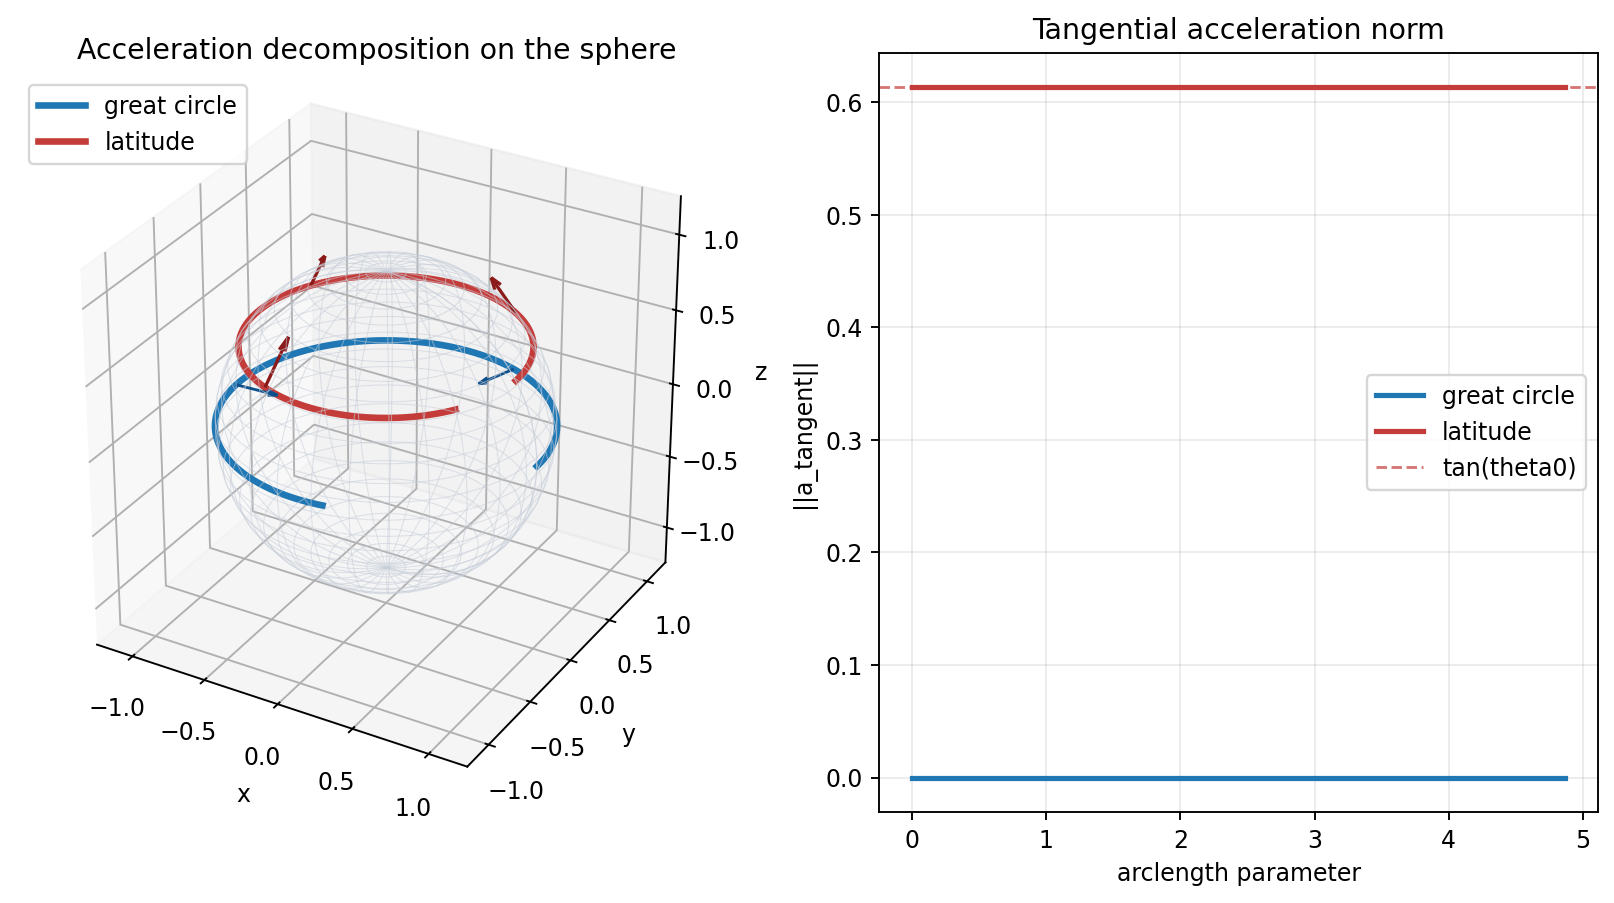

{'great_circle_max_tangent_acceleration': 2.482534153247273e-16,
 'latitude_min_tangent_acceleration': 0.6131052132881356,
 'latitude_expected_tangent_acceleration': 0.6131052132881357,
 'latitude_theta0_radians': 0.55}

In [3]:
s = np.linspace(0.0, 1.55 * np.pi, 260)

great = np.column_stack([np.cos(s), np.sin(s), np.zeros_like(s)])
great_accel = -great
great_tangent = tangent_residual(great_accel, great)
great_residual = np.linalg.norm(great_tangent, axis=1)

theta0 = 0.55
r0 = float(np.cos(theta0))
z0 = float(np.sin(theta0))
phi = s / r0
latitude = np.column_stack([r0 * np.cos(phi), r0 * np.sin(phi), np.full_like(phi, z0)])
latitude_accel = np.column_stack([-(1 / r0) * np.cos(phi), -(1 / r0) * np.sin(phi), np.zeros_like(phi)])
latitude_tangent = tangent_residual(latitude_accel, latitude)
latitude_residual = np.linalg.norm(latitude_tangent, axis=1)

fig = plt.figure(figsize=(12, 5.8))
ax = fig.add_subplot(1, 2, 1, projection="3d")
u = np.linspace(-np.pi / 2, np.pi / 2, 28)
v = np.linspace(0, 2 * np.pi, 56)
U, V = np.meshgrid(u, v, indexing="ij")
X = np.cos(U) * np.cos(V)
Y = np.cos(U) * np.sin(V)
Z = np.sin(U)
ax.plot_wireframe(X, Y, Z, color="#c7ced9", linewidth=0.45, alpha=0.55)
ax.plot(great[:, 0], great[:, 1], great[:, 2], color="#1f77b4", lw=2.8, label="great circle")
ax.plot(latitude[:, 0], latitude[:, 1], latitude[:, 2], color="#c43c39", lw=2.8, label="latitude")
for idx in [45, 120, 195]:
    p = latitude[idx]
    vec = 0.32 * latitude_tangent[idx] / np.linalg.norm(latitude_tangent[idx])
    ax.quiver(p[0], p[1], p[2], vec[0], vec[1], vec[2], color="#8b1a1a", linewidth=1.4, arrow_length_ratio=0.28)
for idx in [65, 170]:
    p = great[idx]
    vec = 0.28 * great_accel[idx]
    ax.quiver(p[0], p[1], p[2], vec[0], vec[1], vec[2], color="#0d4f8b", linewidth=1.2, arrow_length_ratio=0.25)
ax.set_title("Acceleration decomposition on the sphere")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend(loc="upper left")
set_equal_3d(ax, 1.25)

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(s, great_residual, color="#1f77b4", lw=2.2, label="great circle")
ax2.plot(s, latitude_residual, color="#c43c39", lw=2.2, label="latitude")
ax2.axhline(np.tan(theta0), color="#c43c39", ls="--", lw=1.2, alpha=0.7, label="tan(theta0)")
ax2.set_title("Tangential acceleration norm")
ax2.set_xlabel("arclength parameter")
ax2.set_ylabel("||a_tangent||")
ax2.grid(True, alpha=0.25)
ax2.legend()

straight_path = save_figure(fig, "straightest-acceleration-decomposition.png")
straight_checks = {
    "great_circle_max_tangent_acceleration": float(great_residual.max()),
    "latitude_min_tangent_acceleration": float(latitude_residual.min()),
    "latitude_expected_tangent_acceleration": float(np.tan(theta0)),
    "latitude_theta0_radians": theta0,
}
save_check(straight_checks, "straightest-acceleration-decomposition.json")
display_artifact(straight_path, width=920)
straight_checks


## 2. The Sphere Geodesic Equations As Diagnostics

In latitude-longitude coordinates on the unit sphere the metric is

$$ds^2 = d\theta^2 + \cos^2(\theta)\,d\phi^2.$$

The geodesic equations become

$$\ddot\theta + \sin\theta\cos\theta\,\dot\phi^2 = 0,\qquad
\ddot\phi - 2\tan\theta\,\dot\theta\dot\phi = 0.$$

The second equation is the conservation law `cos(theta)^2 phi_dot = constant`, and the full solution should also stay in a plane through the origin. The next cell integrates the ODE from one initial point and tangent direction, then checks three independent signals: metric speed, conserved momentum, and great-circle plane residual. The Plotly artifact is included because rotating the curve makes the planar nature of the geodesic easier to see than a fixed camera view.


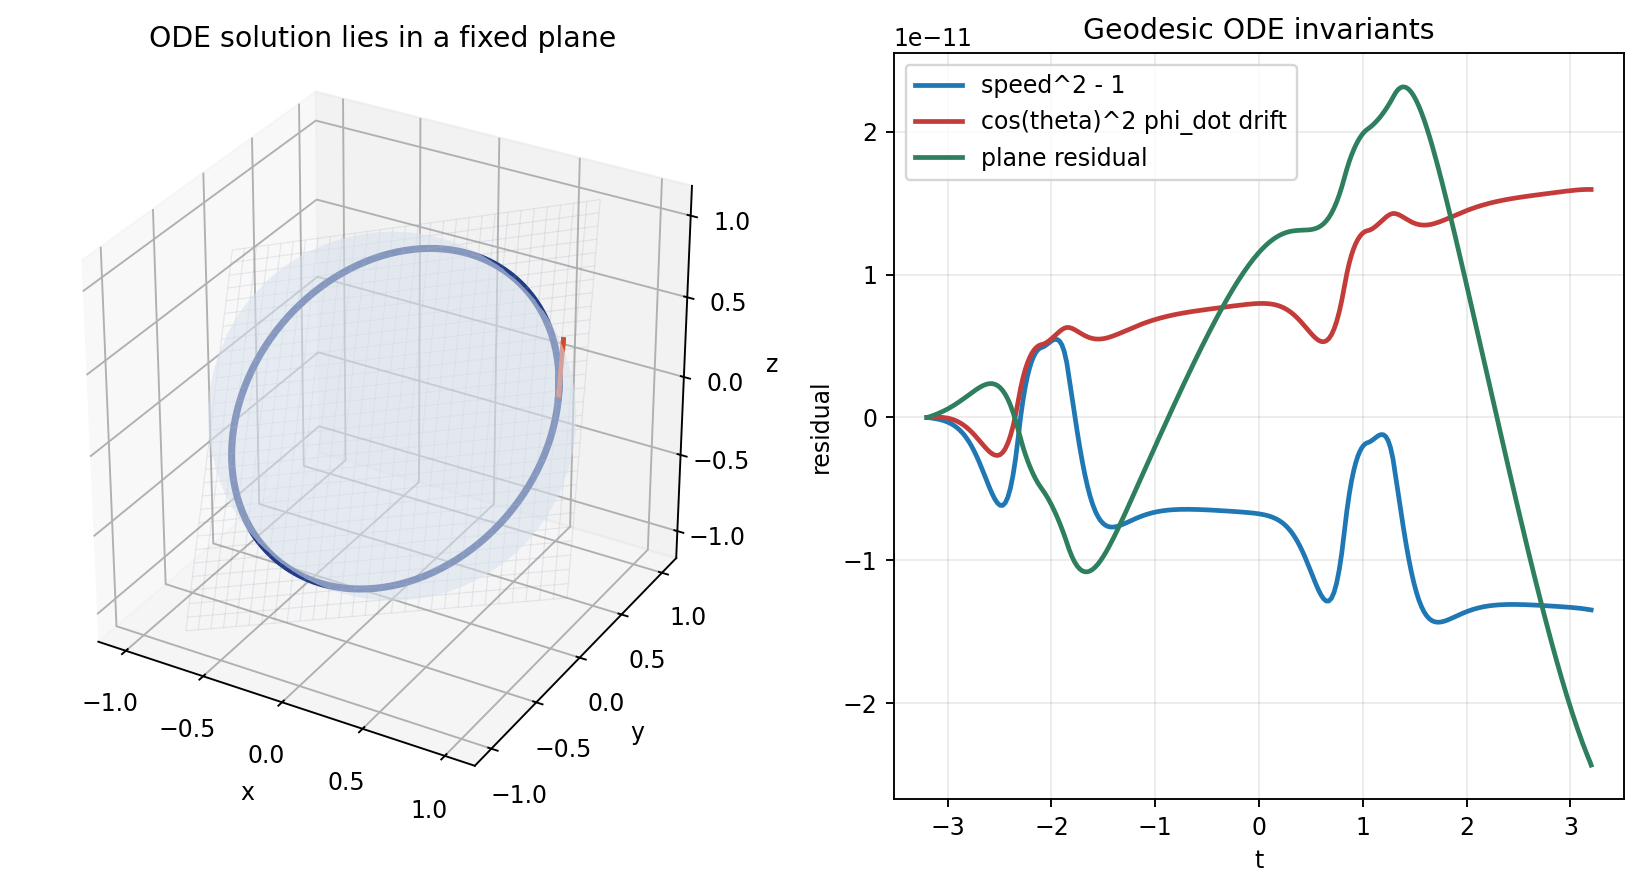

{'sample_count': 271,
 'max_speed2_error': 1.4320655772337432e-11,
 'max_momentum_drift': 1.5951462373209324e-11,
 'max_plane_residual': 2.4317866051255683e-11,
 'initial_momentum': 0.7316126419440548}

In [4]:
def sphere_geodesic_ode(t, y):
    theta, phi, theta_dot, phi_dot = y
    return np.array([
        theta_dot,
        phi_dot,
        -np.sin(theta) * np.cos(theta) * phi_dot**2,
        2 * np.tan(theta) * theta_dot * phi_dot,
    ])

init_theta = 0.32
init_phi = 0.15
initial_angle = 0.88
init_theta_dot = np.cos(initial_angle)
init_phi_dot = np.sin(initial_angle) / np.cos(init_theta)
y0 = np.array([init_theta, init_phi, init_theta_dot, init_phi_dot])

sol = solve_ivp(sphere_geodesic_ode, (-3.2, 3.2), y0, rtol=2e-10, atol=2e-12, max_step=0.025)
assert sol.success, sol.message
theta, phi, theta_dot, phi_dot = sol.y
pts = sphere_xyz(theta, phi)
speed2 = theta_dot**2 + (np.cos(theta) ** 2) * phi_dot**2
momentum = (np.cos(theta) ** 2) * phi_dot

p0 = sphere_xyz(np.array([init_theta]), np.array([init_phi]))[0]
e_theta0 = np.array([-np.sin(init_theta) * np.cos(init_phi), -np.sin(init_theta) * np.sin(init_phi), np.cos(init_theta)])
e_phi0 = np.array([-np.sin(init_phi), np.cos(init_phi), 0.0])
v0 = init_theta_dot * e_theta0 + init_phi_dot * np.cos(init_theta) * e_phi0
plane_normal = np.cross(p0, v0)
plane_normal = plane_normal / np.linalg.norm(plane_normal)
plane_residual = pts @ plane_normal

fig = plt.figure(figsize=(12.2, 5.7))
ax = fig.add_subplot(1, 2, 1, projection="3d")
U, V = np.meshgrid(np.linspace(-np.pi / 2, np.pi / 2, 34), np.linspace(0, 2 * np.pi, 68), indexing="ij")
X = np.cos(U) * np.cos(V)
Y = np.cos(U) * np.sin(V)
Z = np.sin(U)
ax.plot_surface(X, Y, Z, color="#d9e3ef", linewidth=0, alpha=0.34, shade=False)
ax.plot(pts[:, 0], pts[:, 1], pts[:, 2], color="#213b85", lw=3.0)
plane_t = np.linspace(-1.15, 1.15, 30)
plane_s = np.linspace(-1.15, 1.15, 30)
A = p0 / np.linalg.norm(p0)
B = v0 / np.linalg.norm(v0)
PP, QQ = np.meshgrid(plane_t, plane_s)
plane = PP[..., None] * A + QQ[..., None] * B
ax.plot_wireframe(plane[..., 0], plane[..., 1], plane[..., 2], color="#7c8da6", alpha=0.16, linewidth=0.5)
ax.quiver(p0[0], p0[1], p0[2], 0.35*v0[0], 0.35*v0[1], 0.35*v0[2], color="#d24b2a", linewidth=2.0, arrow_length_ratio=0.22)
ax.set_title("ODE solution lies in a fixed plane")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
set_equal_3d(ax, 1.18)

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(sol.t, speed2 - 1.0, label="speed^2 - 1", color="#1f77b4", lw=2)
ax2.plot(sol.t, momentum - momentum[0], label="cos(theta)^2 phi_dot drift", color="#c43c39", lw=2)
ax2.plot(sol.t, plane_residual, label="plane residual", color="#2d7f5e", lw=2)
ax2.set_title("Geodesic ODE invariants")
ax2.set_xlabel("t")
ax2.set_ylabel("residual")
ax2.grid(True, alpha=0.25)
ax2.legend()

sphere_diag_path = save_figure(fig, "sphere-geodesic-ode-diagnostics.png")

mesh_theta, mesh_phi = np.meshgrid(np.linspace(-np.pi / 2, np.pi / 2, 45), np.linspace(0, 2 * np.pi, 90), indexing="ij")
mesh_x = np.cos(mesh_theta) * np.cos(mesh_phi)
mesh_y = np.cos(mesh_theta) * np.sin(mesh_phi)
mesh_z = np.sin(mesh_theta)
plotly_fig = go.Figure()
plotly_fig.add_trace(go.Surface(x=mesh_x, y=mesh_y, z=mesh_z, opacity=0.35, colorscale="Blues", showscale=False, name="unit sphere"))
plotly_fig.add_trace(go.Scatter3d(x=pts[:, 0], y=pts[:, 1], z=pts[:, 2], mode="lines", line=dict(color="#d24b2a", width=7), name="geodesic ODE trace"))
plotly_fig.add_trace(go.Scatter3d(x=[p0[0], p0[0] + 0.5*v0[0]], y=[p0[1], p0[1] + 0.5*v0[1]], z=[p0[2], p0[2] + 0.5*v0[2]], mode="lines", line=dict(color="#111111", width=5), name="initial tangent"))
plotly_fig.update_layout(title="Sphere geodesic flow: rotate to inspect the great-circle plane", scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"), margin=dict(l=0, r=0, t=45, b=0), height=650)
sphere_html_path = save_html(plotly_fig, "sphere-geodesic-flow.html")

sphere_checks = {
    "sample_count": int(sol.t.size),
    "max_speed2_error": float(np.max(np.abs(speed2 - 1.0))),
    "max_momentum_drift": float(np.max(np.abs(momentum - momentum[0]))),
    "max_plane_residual": float(np.max(np.abs(plane_residual))),
    "initial_momentum": float(momentum[0]),
}
save_check(sphere_checks, "sphere-geodesic-ode-diagnostics.json")
display_artifact(sphere_diag_path, width=940)
display_artifact(sphere_html_path, width="100%", height=560)
sphere_checks


## 3. Local Isometry: Plane Lines Become Cylinder Helices

The coordinate equations are not the only way to find geodesics. If two surfaces have the same first fundamental form in corresponding patches, geodesics are carried from one to the other. The unit cylinder is locally isometric to the plane by wrapping `(u,z)` to `(cos u, sin u, z)`. A straight line in the unwrapped plane therefore becomes a circular helix on the cylinder.

This example is deliberately computationally simple: the helix has constant speed and its acceleration is exactly radial, hence normal to the cylinder. That gives a direct residual check and a concrete picture of why an isometry result can produce geodesics without solving a new ODE.


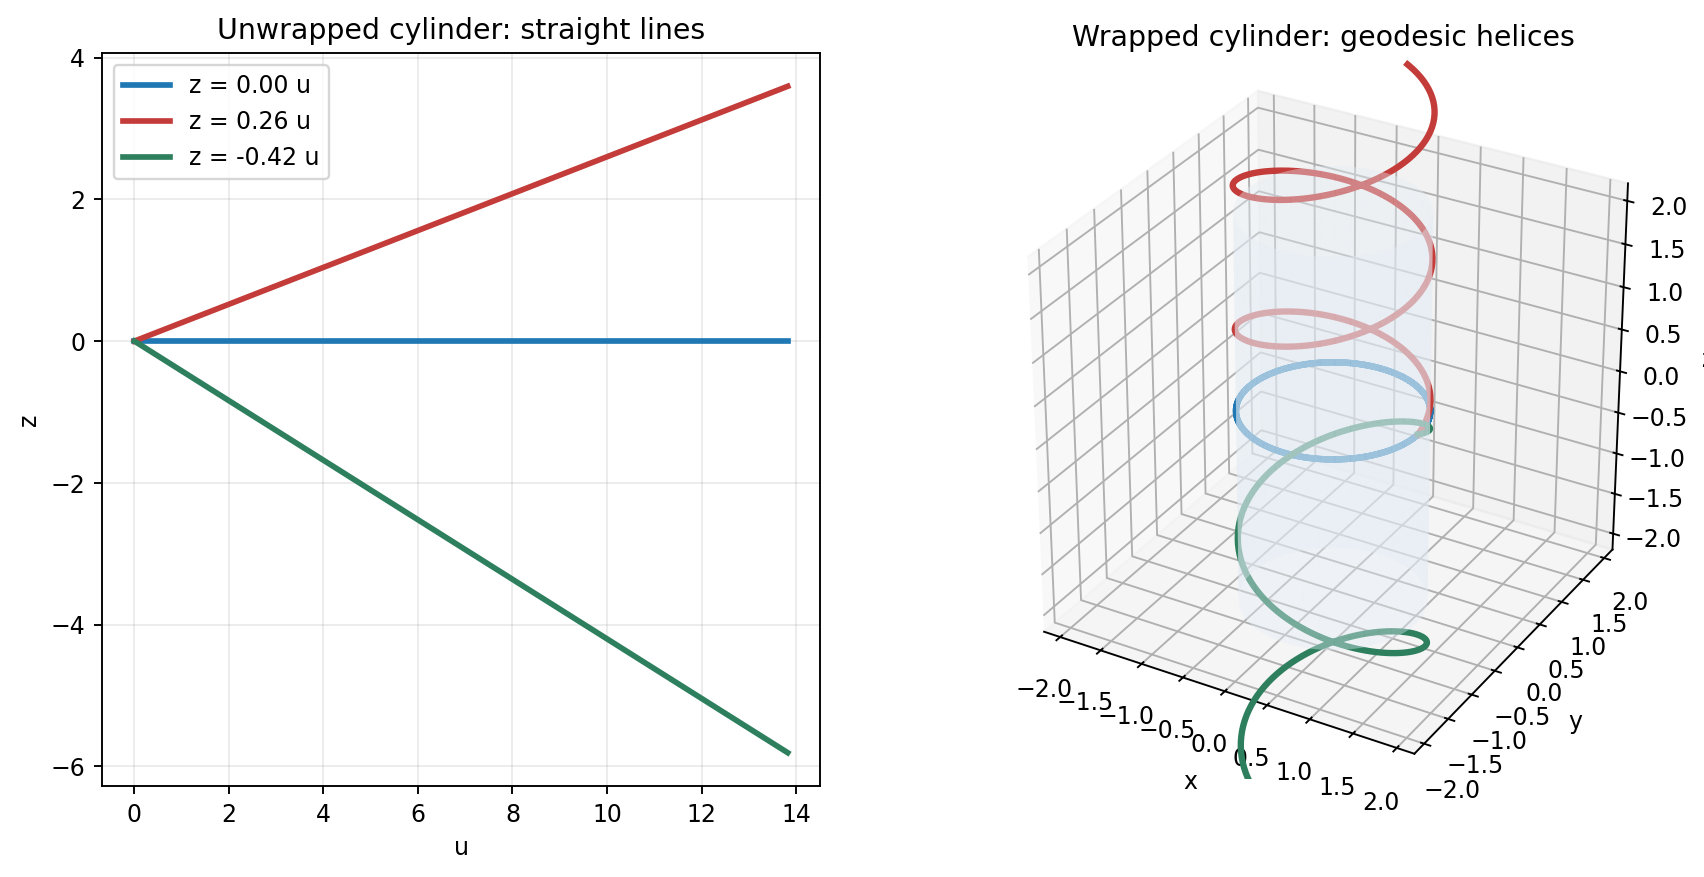

{'map': '(u,z) -> (cos u, sin u, z)',
 'line_to_helix_samples': [{'pitch': 0.0,
   'speed': 1.0,
   'max_tangent_acceleration_residual': 2.482534153247273e-16},
  {'pitch': 0.26,
   'speed': 1.0332473082471592,
   'max_tangent_acceleration_residual': 2.482534153247273e-16},
  {'pitch': -0.42,
   'speed': 1.0846197490365,
   'max_tangent_acceleration_residual': 2.482534153247273e-16}],
 'max_tangent_acceleration_residual': 2.482534153247273e-16}

In [5]:
u_line = np.linspace(0, 4.4 * np.pi, 440)
pitches = [0.0, 0.26, -0.42]

fig = plt.figure(figsize=(12, 5.6))
ax1 = fig.add_subplot(1, 2, 1)
for pitch, color in zip(pitches, ["#1f77b4", "#c43c39", "#2d7f5e"]):
    z_line = pitch * u_line
    ax1.plot(u_line, z_line, color=color, lw=2.4, label=f"z = {pitch:.2f} u")
ax1.set_title("Unwrapped cylinder: straight lines")
ax1.set_xlabel("u")
ax1.set_ylabel("z")
ax1.grid(True, alpha=0.25)
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
U, Zg = np.meshgrid(np.linspace(0, 2*np.pi, 80), np.linspace(-2.3, 2.3, 32))
ax2.plot_surface(np.cos(U), np.sin(U), Zg, color="#e4edf5", alpha=0.4, linewidth=0, shade=False)
helix_checks = []
for pitch, color in zip(pitches, ["#1f77b4", "#c43c39", "#2d7f5e"]):
    z_line = pitch * u_line
    curve = np.column_stack([np.cos(u_line), np.sin(u_line), z_line])
    ax2.plot(curve[:, 0], curve[:, 1], curve[:, 2], color=color, lw=2.7)
    velocity = np.column_stack([-np.sin(u_line), np.cos(u_line), np.full_like(u_line, pitch)])
    accel = np.column_stack([-np.cos(u_line), -np.sin(u_line), np.zeros_like(u_line)])
    normal = np.column_stack([np.cos(u_line), np.sin(u_line), np.zeros_like(u_line)])
    residual = tangent_residual(accel, normal)
    helix_checks.append({
        "pitch": float(pitch),
        "speed": float(np.linalg.norm(velocity[0])),
        "max_tangent_acceleration_residual": float(np.linalg.norm(residual, axis=1).max()),
    })
ax2.set_title("Wrapped cylinder: geodesic helices")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
set_equal_3d(ax2, 2.2, center=(0, 0, 0))

cylinder_path = save_figure(fig, "cylinder-local-isometry-helix.png")
cylinder_checks = {
    "map": "(u,z) -> (cos u, sin u, z)",
    "line_to_helix_samples": helix_checks,
    "max_tangent_acceleration_residual": float(max(item["max_tangent_acceleration_residual"] for item in helix_checks)),
}
save_check(cylinder_checks, "cylinder-local-isometry-helix.json")
display_artifact(cylinder_path, width=920)
cylinder_checks


## 4. Clairaut's Theorem As A Surface-Of-Revolution Lab

For a surface of revolution parametrized by arclength along the profile,

$$\sigma(u,v) = (\rho(u)\cos v, \rho(u)\sin v, z(u)), \qquad ds^2 = du^2 + \rho(u)^2 dv^2.$$

The geodesic equations imply the conserved angular momentum

$$\Omega = \rho(u)^2\dot v = \rho\sin\psi,$$

where `psi` is the angle from the meridian direction. The conservation law is not just a formula: it controls where the geodesic can go. Since unit speed gives `u_dot^2 = 1 - Omega^2/rho^2`, a geodesic can only enter regions where `rho >= |Omega|`. The lab below uses a smooth profile with a varying radius. Low angular momentum crosses the necks; larger angular momentum turns before it reaches small-radius bands.


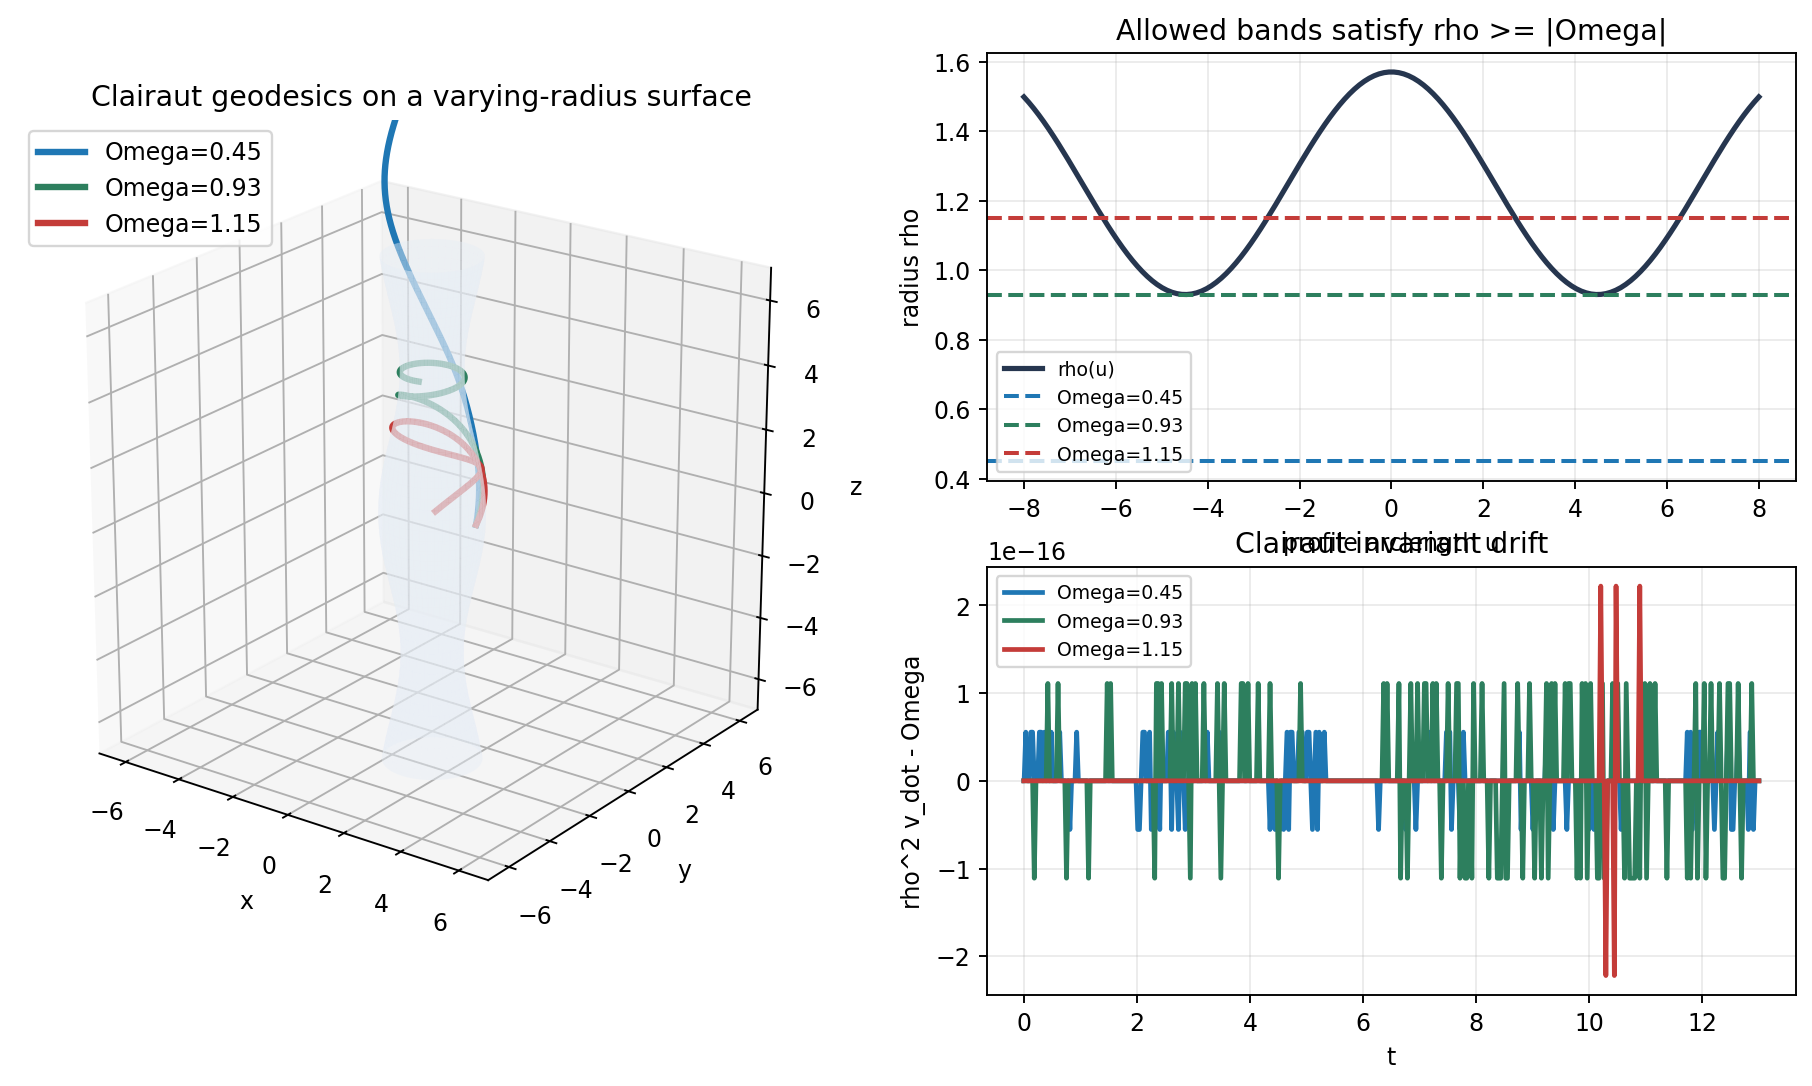

,Omega,u_min,u_max,rho_min_on_path,max_speed2_error,max_clairaut_drift
0,0.45,0.000000,12.071790,0.930003,6.772360e-15,5.551115e-17
1,0.93,0.000000,4.443857,0.930153,4.218847e-15,1.110223e-16
2,1.15,-0.574621,2.698016,1.150003,2.775558e-14,2.220446e-16


{'profile_radius_min_sampled': 0.9300783516354403,
 'profile_radius_max_sampled': 1.569774018765191,
 'max_speed2_error': 2.7755575615628914e-14,
 'max_clairaut_drift': 2.220446049250313e-16,
 'lab_csv': 'artifacts\\chapter-09\\tables\\clairaut-lab.csv',
 'rows': [{'Omega': 0.45,
   'u_min': 0.0,
   'u_max': 12.07179021872758,
   'rho_min_on_path': 0.9300029951105668,
   'max_speed2_error': 6.772360450213455e-15,
   'max_clairaut_drift': 5.551115123125783e-17},
  {'Omega': 0.93,
   'u_min': 0.0,
   'u_max': 4.443856803981819,
   'rho_min_on_path': 0.9301526871684156,
   'max_speed2_error': 4.218847493575595e-15,
   'max_clairaut_drift': 1.1102230246251565e-16},
  {'Omega': 1.15,
   'u_min': -0.5746206642868107,
   'u_max': 2.69801618594106,
   'rho_min_on_path': 1.1500026447462797,
   'max_speed2_error': 2.7755575615628914e-14,
   'max_clairaut_drift': 2.220446049250313e-16}]}

In [6]:
def rho(u):
    return 1.25 + 0.32 * np.cos(0.7 * u)


def rho_prime(u):
    return -0.224 * np.sin(0.7 * u)

u_profile = np.linspace(-14, 14, 2400)
z_profile = cumulative_trapezoid(np.sqrt(1 - rho_prime(u_profile) ** 2), u_profile, initial=0.0)
z_profile = z_profile - np.interp(0.0, u_profile, z_profile)


def z_of_u(u):
    return np.interp(u, u_profile, z_profile)


def clairaut_ode(t, y, Omega):
    u, v, u_dot = y
    r = rho(u)
    v_dot = Omega / (r * r)
    u_ddot = rho_prime(u) * Omega * Omega / (r**3)
    return np.array([u_dot, v_dot, u_ddot])

Omegas = [0.45, 0.93, 1.15]
colors = ["#1f77b4", "#2d7f5e", "#c43c39"]
solutions = []
for Omega in Omegas:
    u0 = 0.0
    v0 = 0.0
    u_dot0 = math.sqrt(max(0.0, 1.0 - (Omega / rho(u0)) ** 2))
    sol_c = solve_ivp(lambda t, y, Om=Omega: clairaut_ode(t, y, Om), (0, 13.0), [u0, v0, u_dot0], max_step=0.03, rtol=3e-9, atol=3e-11)
    assert sol_c.success, sol_c.message
    u_vals, v_vals, u_dot_vals = sol_c.y
    r_vals = rho(u_vals)
    v_dot_vals = Omega / (r_vals * r_vals)
    speed2_vals = u_dot_vals**2 + r_vals**2 * v_dot_vals**2
    omega_vals = r_vals**2 * v_dot_vals
    solutions.append({
        "Omega": Omega,
        "t": sol_c.t,
        "u": u_vals,
        "v": v_vals,
        "u_dot": u_dot_vals,
        "v_dot": v_dot_vals,
        "speed2": speed2_vals,
        "omega": omega_vals,
        "xyz": np.column_stack([r_vals * np.cos(v_vals), r_vals * np.sin(v_vals), z_of_u(u_vals)]),
    })

fig = plt.figure(figsize=(13.5, 7.2))
ax = fig.add_subplot(2, 2, (1, 3), projection="3d")
u_vis = np.linspace(-8.0, 8.0, 150)
v_vis = np.linspace(0, 2*np.pi, 92)
UU, VV = np.meshgrid(u_vis, v_vis, indexing="ij")
RR = rho(UU)
ZZ = z_of_u(UU)
ax.plot_surface(RR*np.cos(VV), RR*np.sin(VV), ZZ, color="#e7eef6", linewidth=0, alpha=0.46, shade=False)
for item, color in zip(solutions, colors):
    xyz = item["xyz"]
    ax.plot(xyz[:, 0], xyz[:, 1], xyz[:, 2], color=color, lw=2.7, label=f"Omega={item['Omega']:.2f}")
ax.set_title("Clairaut geodesics on a varying-radius surface")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend(loc="upper left")
ax.view_init(elev=22, azim=-54)
set_equal_3d(ax, 7.0, center=(0, 0, 0))

ax_profile = fig.add_subplot(2, 2, 2)
ax_profile.plot(u_vis, rho(u_vis), color="#26364f", lw=2.2, label="rho(u)")
for Omega, color in zip(Omegas, colors):
    ax_profile.axhline(Omega, color=color, lw=1.7, ls="--", label=f"Omega={Omega:.2f}")
ax_profile.set_title("Allowed bands satisfy rho >= |Omega|")
ax_profile.set_xlabel("profile arclength u")
ax_profile.set_ylabel("radius rho")
ax_profile.grid(True, alpha=0.25)
ax_profile.legend(fontsize=8)

ax_resid = fig.add_subplot(2, 2, 4)
for item, color in zip(solutions, colors):
    ax_resid.plot(item["t"], item["omega"] - item["Omega"], color=color, lw=2.0, label=f"Omega={item['Omega']:.2f}")
ax_resid.set_title("Clairaut invariant drift")
ax_resid.set_xlabel("t")
ax_resid.set_ylabel("rho^2 v_dot - Omega")
ax_resid.grid(True, alpha=0.25)
ax_resid.legend(fontsize=8)

clairaut_path = save_figure(fig, "clairaut-invariant-surface-of-revolution.png")

lab_rows = []
for item in solutions:
    lab_rows.append({
        "Omega": item["Omega"],
        "u_min": float(np.min(item["u"])),
        "u_max": float(np.max(item["u"])),
        "rho_min_on_path": float(np.min(rho(item["u"]))),
        "max_speed2_error": float(np.max(np.abs(item["speed2"] - 1.0))),
        "max_clairaut_drift": float(np.max(np.abs(item["omega"] - item["Omega"]))),
    })
clairaut_lab = pd.DataFrame(lab_rows)
clairaut_table_path = save_table(clairaut_lab, "clairaut-lab.csv")
clairaut_checks = {
    "profile_radius_min_sampled": float(np.min(rho(u_vis))),
    "profile_radius_max_sampled": float(np.max(rho(u_vis))),
    "max_speed2_error": float(clairaut_lab["max_speed2_error"].max()),
    "max_clairaut_drift": float(clairaut_lab["max_clairaut_drift"].max()),
    "lab_csv": str(clairaut_table_path.relative_to(BOOK_ROOT)),
    "rows": lab_rows,
}
save_check(clairaut_checks, "clairaut-invariant-surface-of-revolution.json")
display_artifact(clairaut_path, width=940)
display(clairaut_lab)
clairaut_checks


## 5. Stationary Length: A Geodesic Need Not Be The Global Shortest Route

The shortest-path theorem in this chapter is a first-variation statement. If a unit-speed curve is geodesic, then every smooth endpoint-fixed variation has zero first derivative of length at the original curve. Conversely, if all such first variations vanish, the geodesic equations follow.

The computation below compares two endpoint-fixed families on the sphere. The equator arc is a geodesic, so the length curve is flat to first order when we push the middle of the arc north or south. A non-equatorial latitude arc with the same style of endpoint-fixed variation has a nonzero first derivative; nudging the middle of the curve toward the equator shortens it. This is the numerical counterpart of the integration-by-parts proof: endpoint terms vanish, and the interior residual decides whether the first variation can be forced away from zero.


C:\Users\rahul\AppData\Local\Temp\ipykernel_11292\851283225.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  length = float(np.trapz(speed, x))
C:\Users\rahul\AppData\Local\Temp\ipykernel_11292\851283225.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = float(np.trapz(speed**2, x))


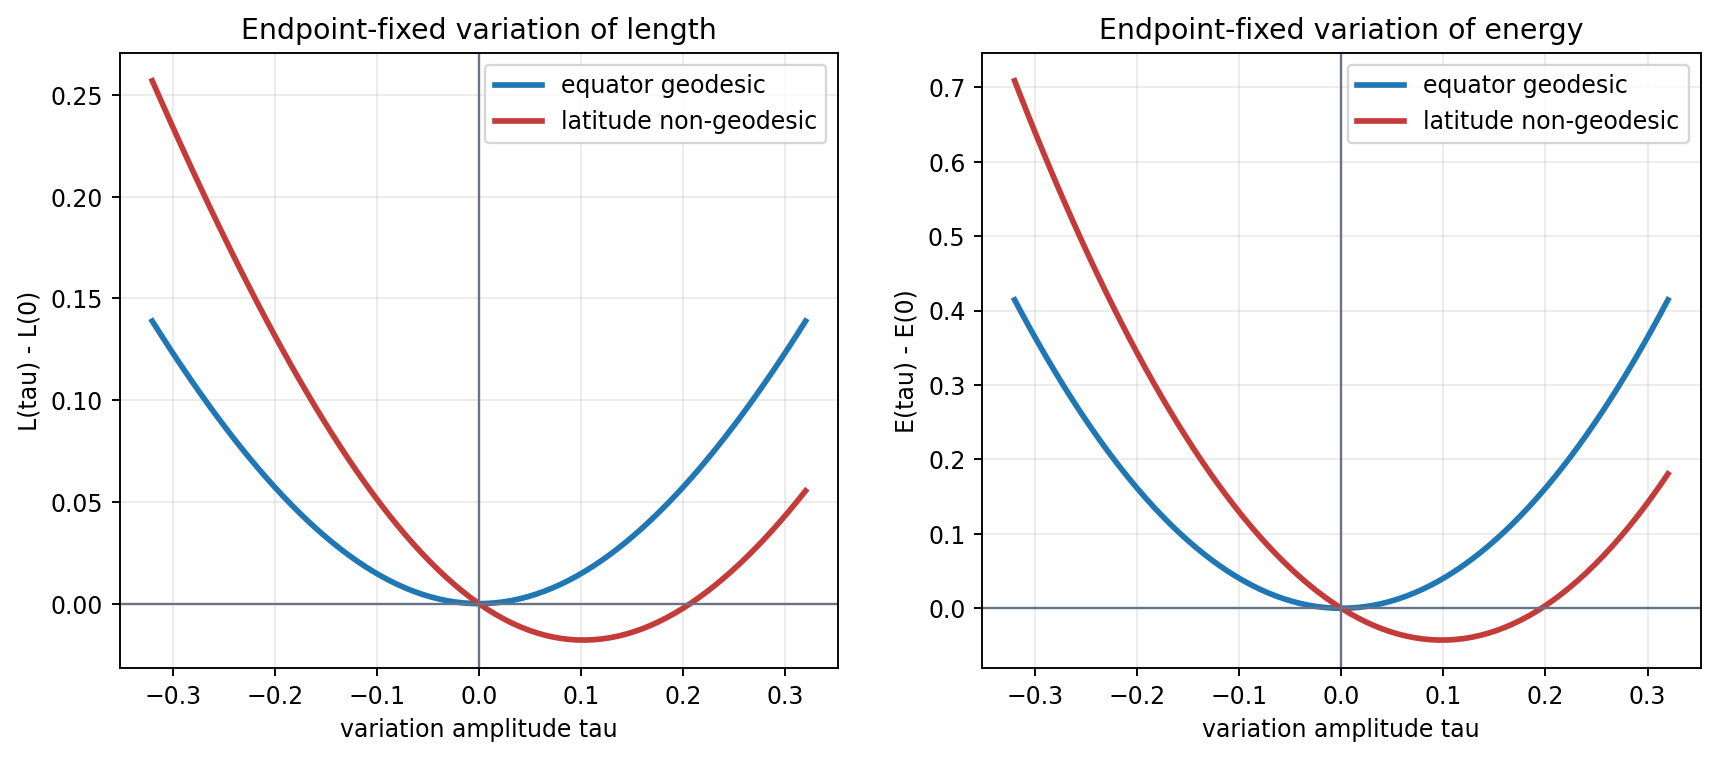

{'geodesic_length_slope': 0.0,
 'latitude_length_slope': -0.3504174377231547,
 'geodesic_energy_slope': 0.0,
 'latitude_energy_slope': -0.8639395930653541,
 'delta_phi': 1.35,
 'latitude_base_theta': 0.42}

In [7]:
def sphere_variation_lengths(theta_base, tau_values, *, delta_phi=1.35, n=1800):
    x = np.linspace(0.0, 1.0, n)
    rows = []
    for tau in tau_values:
        theta = theta_base + tau * np.sin(np.pi * x)
        theta_x = tau * np.pi * np.cos(np.pi * x)
        phi_x = np.full_like(x, delta_phi)
        speed = np.sqrt(theta_x**2 + (np.cos(theta) ** 2) * phi_x**2)
        length = float(np.trapz(speed, x))
        energy = float(np.trapz(speed**2, x))
        rows.append({"tau": float(tau), "length": length, "energy": energy})
    return pd.DataFrame(rows)

taus = np.linspace(-0.32, 0.32, 81)
geodesic_var = sphere_variation_lengths(0.0, taus)
latitude_var = sphere_variation_lengths(0.42, taus)

def central_slope(df, column, h_index=1):
    mid = len(df) // 2
    h = df.loc[mid + h_index, "tau"] - df.loc[mid, "tau"]
    return float((df.loc[mid + h_index, column] - df.loc[mid - h_index, column]) / (2*h))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
for ax, column, ylabel in [(axes[0], "length", "L(tau) - L(0)"), (axes[1], "energy", "E(tau) - E(0)")]:
    for df, label, color in [(geodesic_var, "equator geodesic", "#1f77b4"), (latitude_var, "latitude non-geodesic", "#c43c39")]:
        base = float(df.loc[len(df)//2, column])
        ax.plot(df["tau"], df[column] - base, color=color, lw=2.4, label=label)
    ax.axvline(0, color="#687386", lw=1.0)
    ax.axhline(0, color="#687386", lw=1.0)
    ax.set_title(f"Endpoint-fixed variation of {column}")
    ax.set_xlabel("variation amplitude tau")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    ax.legend()

variation_path = save_figure(fig, "variation-first-variation-length.png")
variation_checks = {
    "geodesic_length_slope": central_slope(geodesic_var, "length"),
    "latitude_length_slope": central_slope(latitude_var, "length"),
    "geodesic_energy_slope": central_slope(geodesic_var, "energy"),
    "latitude_energy_slope": central_slope(latitude_var, "energy"),
    "delta_phi": 1.35,
    "latitude_base_theta": 0.42,
}
save_check(variation_checks, "variation-first-variation-length.json")
display_artifact(variation_path, width=920)
variation_checks


## 6. Exponential Map, Cut-Locus Intuition, And Geodesic Coordinates

The existence-and-uniqueness theorem says that a point and a tangent direction determine one local geodesic. The exponential map packages that statement: a tangent vector says which geodesic to follow and for how long. On a sphere based at the north pole, all vectors of length `pi` land at the south pole, so geodesic polar coordinates stop being one-to-one there. This is the cut-locus warning behind local coordinate claims: geodesic coordinates are reliable near the base point or base geodesic, not automatically global.

The second artifact uses the standard sphere patch

$$\sigma(u,v)=(\cos u\cos v,\cos u\sin v,\sin u).$$

Here the equator is the base geodesic and the meridians are perpendicular geodesics. SymPy verifies the metric coefficients exactly: `E=1`, `F=0`, `G=cos(u)^2`, so `G(0,v)=1` and `G_u(0,v)=0`. This is the concrete sphere model for the geodesic-coordinate proposition.


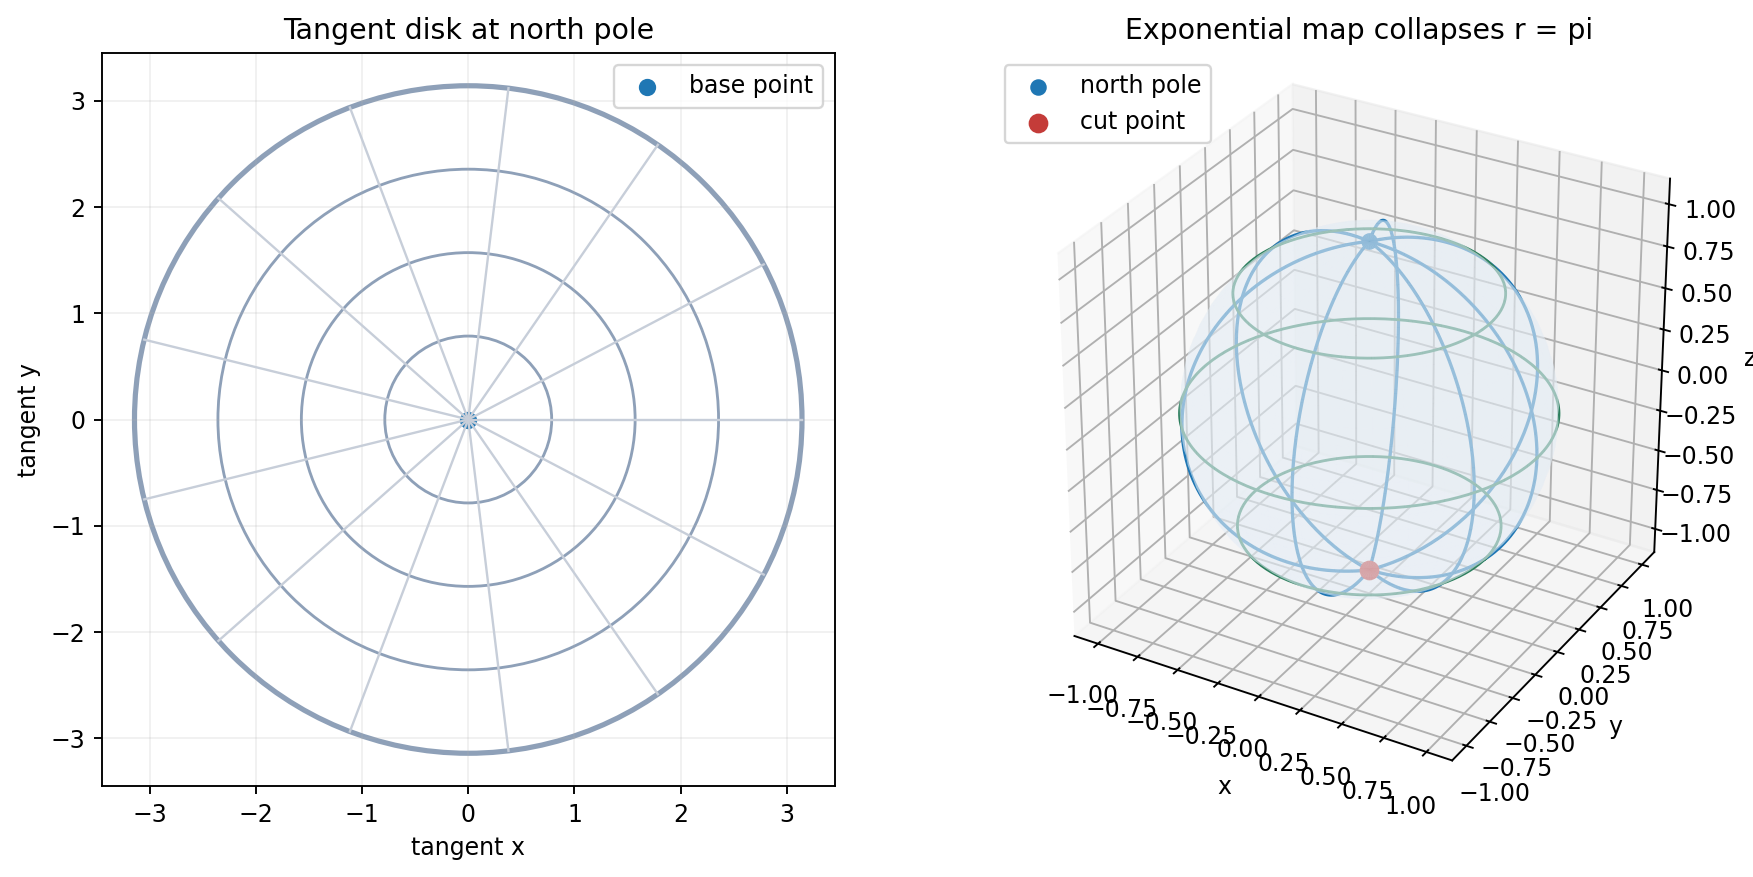

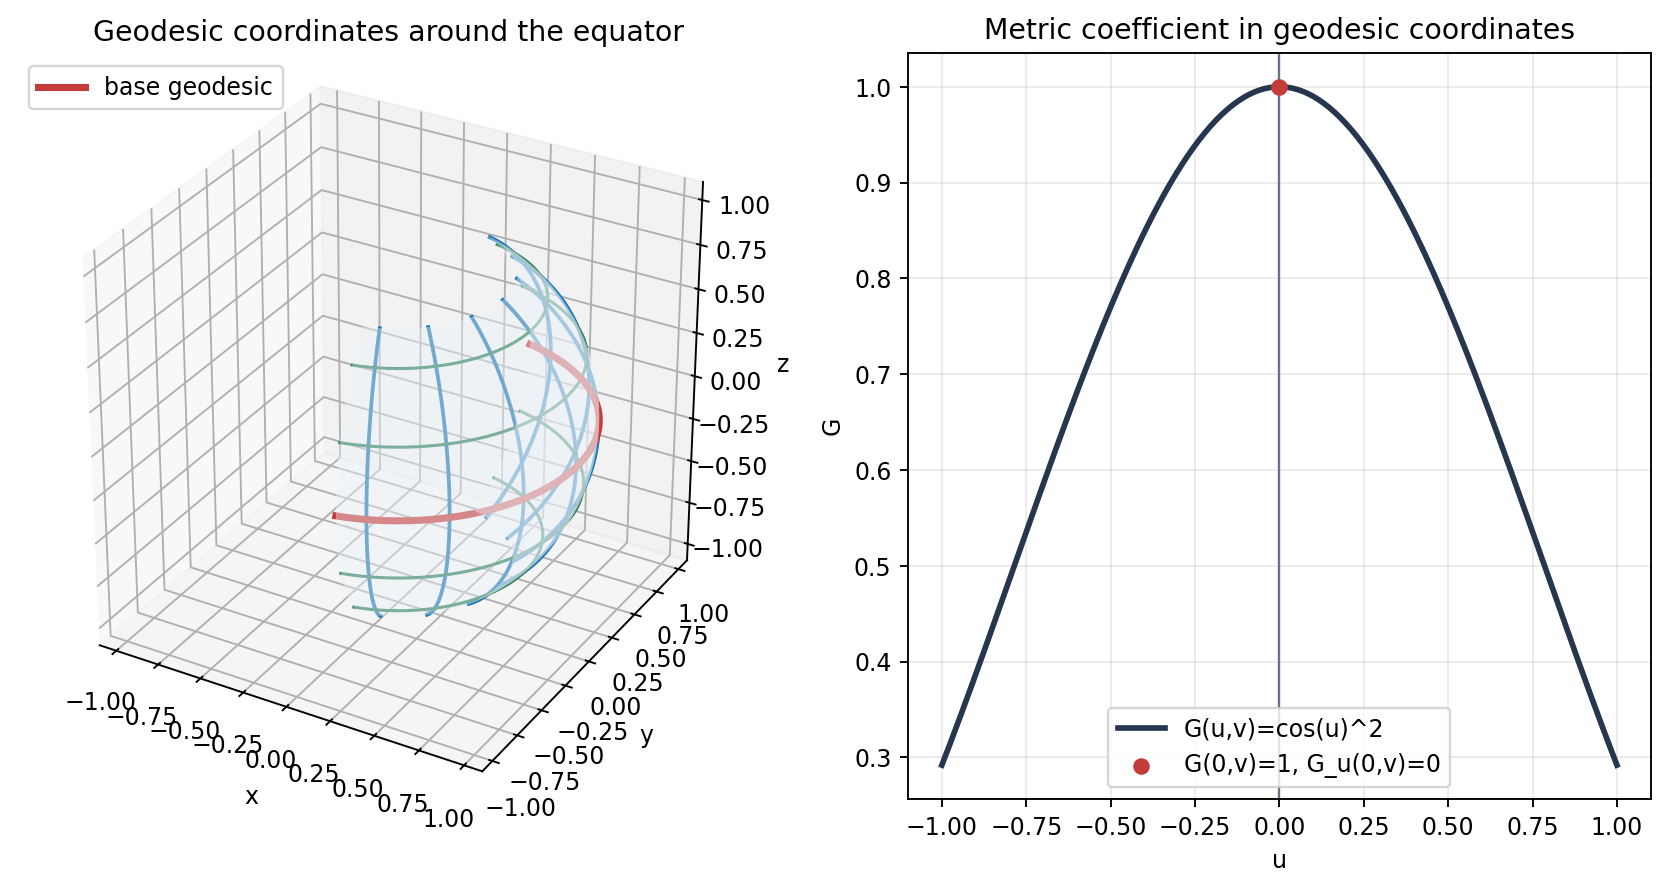

{'E': '1', 'F': '0', 'G': 'cos(u)**2', 'G_at_u0': '1', 'Gu_at_u0': '0'}

In [8]:
def exp_north(r, alpha):
    return np.column_stack([np.sin(r) * np.cos(alpha), np.sin(r) * np.sin(alpha), np.cos(r)])

fig = plt.figure(figsize=(12.4, 5.6))
ax1 = fig.add_subplot(1, 2, 1)
angles = np.linspace(0, 2*np.pi, 13, endpoint=False)
radii = [np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
for rad in radii:
    circle = plt.Circle((0, 0), rad, fill=False, color="#8ea0b8", lw=1.2 if rad < np.pi else 2.2)
    ax1.add_patch(circle)
for alpha in angles:
    ax1.plot([0, np.pi*np.cos(alpha)], [0, np.pi*np.sin(alpha)], color="#c7ced9", lw=1.0)
ax1.scatter([0], [0], color="#1f77b4", s=40, label="base point")
ax1.set_title("Tangent disk at north pole")
ax1.set_xlabel("tangent x")
ax1.set_ylabel("tangent y")
ax1.set_aspect("equal")
ax1.set_xlim(-3.45, 3.45)
ax1.set_ylim(-3.45, 3.45)
ax1.grid(True, alpha=0.18)
ax1.legend(loc="upper right")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
U, V = np.meshgrid(np.linspace(-np.pi / 2, np.pi / 2, 34), np.linspace(0, 2*np.pi, 68), indexing="ij")
ax2.plot_surface(np.cos(U)*np.cos(V), np.cos(U)*np.sin(V), np.sin(U), color="#e4edf5", alpha=0.38, linewidth=0, shade=False)
for alpha in angles[::2]:
    rr = np.linspace(0, np.pi, 200)
    ray = exp_north(rr, np.full_like(rr, alpha))
    ax2.plot(ray[:, 0], ray[:, 1], ray[:, 2], color="#1f77b4", lw=1.4)
for rad in radii[:-1]:
    aa = np.linspace(0, 2*np.pi, 220)
    circle = exp_north(np.full_like(aa, rad), aa)
    ax2.plot(circle[:, 0], circle[:, 1], circle[:, 2], color="#2d7f5e", lw=1.2)
south = exp_north(np.array([np.pi]), np.array([0.0]))[0]
ax2.scatter([0], [0], [1], color="#1f77b4", s=36, label="north pole")
ax2.scatter([south[0]], [south[1]], [south[2]], color="#c43c39", s=54, label="cut point")
ax2.set_title("Exponential map collapses r = pi")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
ax2.legend(loc="upper left")
set_equal_3d(ax2, 1.15)

exp_path = save_figure(fig, "sphere-exponential-map-cut-locus.png")
antipodal_points = exp_north(np.full(40, np.pi), np.linspace(0, 2*np.pi, 40, endpoint=False))
antipodal_spread = float(np.max(np.linalg.norm(antipodal_points - antipodal_points[0], axis=1)))
r_test = np.linspace(0, np.pi - 1e-3, 100)
a_test = np.linspace(0.1, 2.4, 100)
points_test = exp_north(r_test, a_test)
dist_from_north = np.arccos(np.clip(points_test[:, 2], -1, 1))
exp_checks = {
    "antipodal_spread_at_r_equals_pi": antipodal_spread,
    "max_radial_distance_error_before_cut": float(np.max(np.abs(dist_from_north - r_test))),
}
save_check(exp_checks, "sphere-exponential-map-cut-locus.json")
display_artifact(exp_path, width=920)

u_sym, v_sym = sp.symbols("u v", real=True)
sigma = sp.Matrix([sp.cos(u_sym)*sp.cos(v_sym), sp.cos(u_sym)*sp.sin(v_sym), sp.sin(u_sym)])
sigma_u = sigma.diff(u_sym)
sigma_v = sigma.diff(v_sym)
E_sym = sp.simplify(sigma_u.dot(sigma_u))
F_sym = sp.simplify(sigma_u.dot(sigma_v))
G_sym = sp.simplify(sigma_v.dot(sigma_v))
Gu0_sym = sp.simplify(sp.diff(G_sym, u_sym).subs(u_sym, 0))
G0_sym = sp.simplify(G_sym.subs(u_sym, 0))
assert E_sym == 1
assert F_sym == 0
assert G0_sym == 1
assert Gu0_sym == 0

fig = plt.figure(figsize=(12.4, 5.7))
ax = fig.add_subplot(1, 2, 1, projection="3d")
U, V = np.meshgrid(np.linspace(-0.95, 0.95, 40), np.linspace(-1.35, 1.35, 58), indexing="ij")
X = np.cos(U)*np.cos(V)
Y = np.cos(U)*np.sin(V)
Z = np.sin(U)
ax.plot_surface(X, Y, Z, color="#edf3f9", alpha=0.42, linewidth=0, shade=False)
for vv in np.linspace(-1.2, 1.2, 7):
    uu = np.linspace(-0.95, 0.95, 150)
    curve = sphere_xyz(uu, np.full_like(uu, vv))
    ax.plot(curve[:, 0], curve[:, 1], curve[:, 2], color="#1f77b4", lw=1.6)
for uu in np.linspace(-0.75, 0.75, 5):
    vv = np.linspace(-1.35, 1.35, 180)
    curve = sphere_xyz(np.full_like(vv, uu), vv)
    ax.plot(curve[:, 0], curve[:, 1], curve[:, 2], color="#2d7f5e", lw=1.3)
base = sphere_xyz(np.zeros(180), np.linspace(-1.35, 1.35, 180))
ax.plot(base[:, 0], base[:, 1], base[:, 2], color="#c43c39", lw=3.0, label="base geodesic")
ax.set_title("Geodesic coordinates around the equator")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend(loc="upper left")
set_equal_3d(ax, 1.1)

axg = fig.add_subplot(1, 2, 2)
u_vals = np.linspace(-1.0, 1.0, 240)
axg.plot(u_vals, np.cos(u_vals)**2, color="#26364f", lw=2.4, label="G(u,v)=cos(u)^2")
axg.scatter([0], [1], color="#c43c39", zorder=3, label="G(0,v)=1, G_u(0,v)=0")
axg.axvline(0, color="#687386", lw=1.0)
axg.set_title("Metric coefficient in geodesic coordinates")
axg.set_xlabel("u")
axg.set_ylabel("G")
axg.grid(True, alpha=0.25)
axg.legend()

coords_path = save_figure(fig, "geodesic-coordinates-gauss-lemma.png")
coords_checks = {
    "E": str(E_sym),
    "F": str(F_sym),
    "G": str(G_sym),
    "G_at_u0": str(G0_sym),
    "Gu_at_u0": str(Gu0_sym),
}
save_check(coords_checks, "geodesic-coordinates-gauss-lemma.json")
display_artifact(coords_path, width=920)
coords_checks


## 7. Proof-State Map

The chapter's proof architecture is a network: the same definition feeds constant speed, zero geodesic curvature, normal sections, ODEs, local isometry, variational length, and coordinate patches. The dependency graph below is not a replacement for a proof, but it prevents a common misconception. "Shortest", "straightest", "ODE solution", and "coordinate line" are not four unrelated meanings of geodesic. They are connected by explicit hypotheses: unit speed, patch coordinates, endpoint-fixed variations, local existence and uniqueness, and sometimes symmetry.


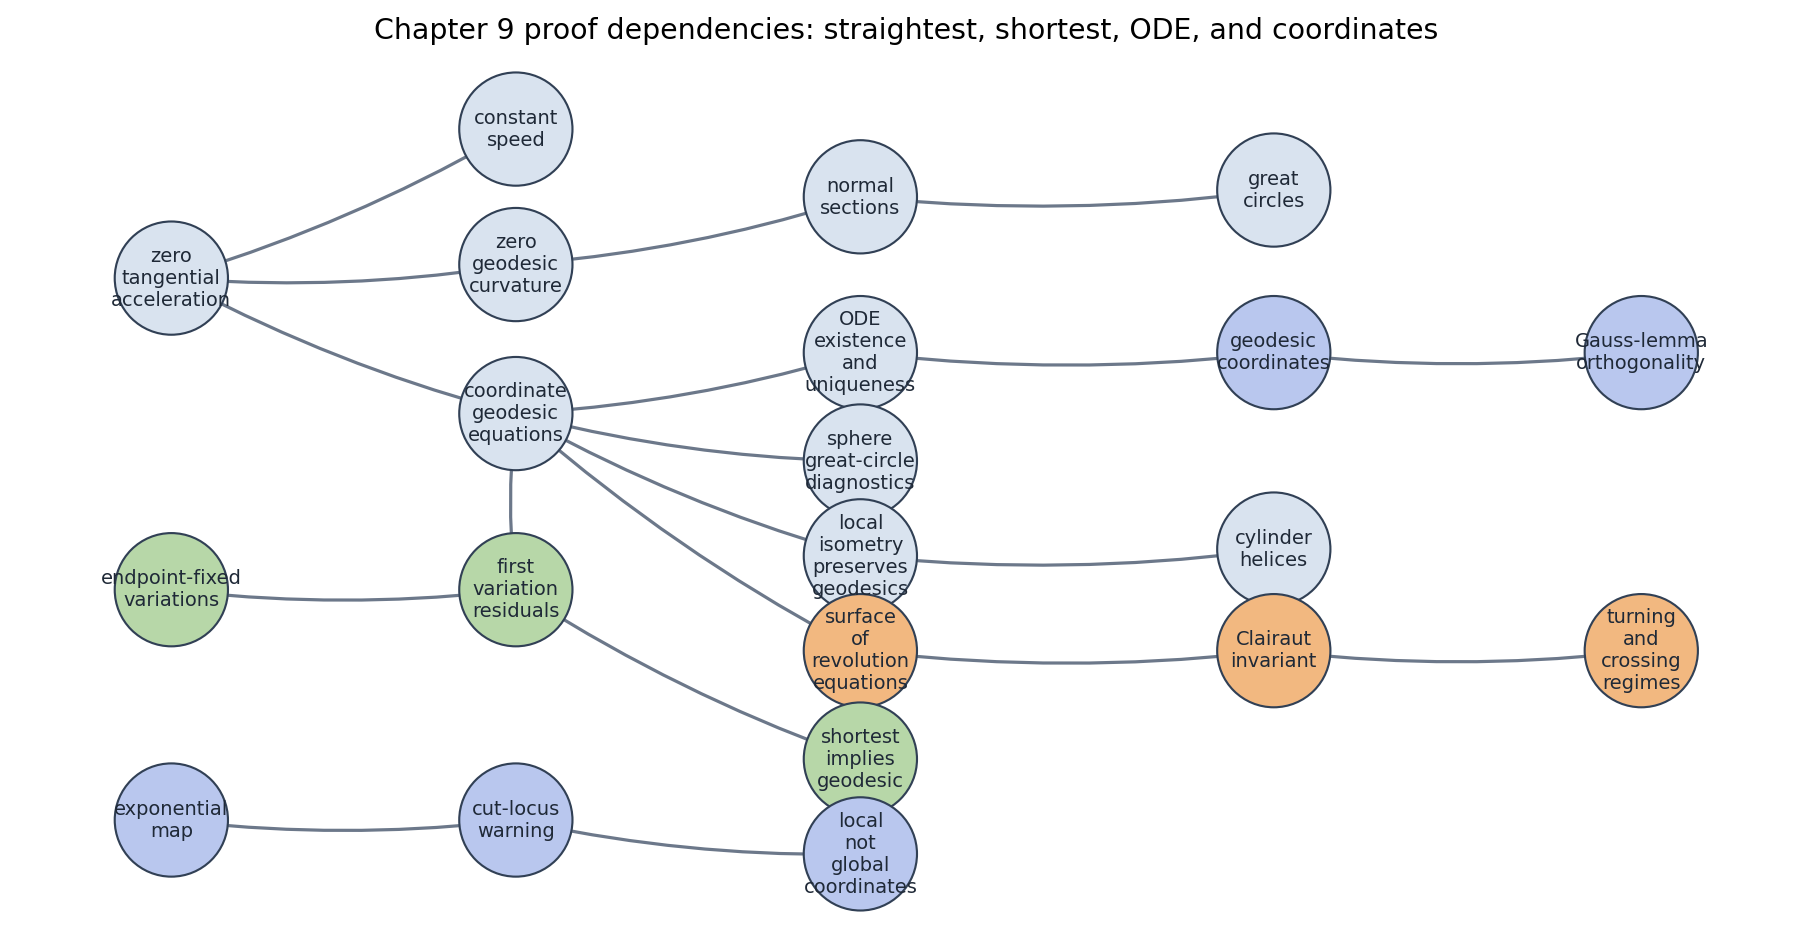

{'node_count': 21,
 'edge_count': 19,
 'is_dag': True,
 'longest_dependency_chain_length': 5}

In [9]:
G = nx.DiGraph()
edges = [
    ("zero tangential acceleration", "constant speed"),
    ("zero tangential acceleration", "zero geodesic curvature"),
    ("zero geodesic curvature", "normal sections"),
    ("normal sections", "great circles"),
    ("zero tangential acceleration", "coordinate geodesic equations"),
    ("coordinate geodesic equations", "ODE existence and uniqueness"),
    ("coordinate geodesic equations", "sphere great-circle diagnostics"),
    ("coordinate geodesic equations", "local isometry preserves geodesics"),
    ("local isometry preserves geodesics", "cylinder helices"),
    ("coordinate geodesic equations", "surface of revolution equations"),
    ("surface of revolution equations", "Clairaut invariant"),
    ("Clairaut invariant", "turning and crossing regimes"),
    ("coordinate geodesic equations", "first variation residuals"),
    ("endpoint-fixed variations", "first variation residuals"),
    ("first variation residuals", "shortest implies geodesic"),
    ("ODE existence and uniqueness", "geodesic coordinates"),
    ("geodesic coordinates", "Gauss-lemma orthogonality"),
    ("exponential map", "cut-locus warning"),
    ("cut-locus warning", "local not global coordinates"),
]
G.add_edges_from(edges)
assert nx.is_directed_acyclic_graph(G)

pos = {
    "zero tangential acceleration": (0, 3),
    "endpoint-fixed variations": (0, 0.7),
    "exponential map": (0, -1.0),
    "constant speed": (1.5, 4.1),
    "zero geodesic curvature": (1.5, 3.1),
    "coordinate geodesic equations": (1.5, 2.0),
    "first variation residuals": (1.5, 0.7),
    "cut-locus warning": (1.5, -1.0),
    "normal sections": (3.0, 3.6),
    "ODE existence and uniqueness": (3.0, 2.45),
    "sphere great-circle diagnostics": (3.0, 1.65),
    "local isometry preserves geodesics": (3.0, 0.95),
    "surface of revolution equations": (3.0, 0.25),
    "shortest implies geodesic": (3.0, -0.55),
    "local not global coordinates": (3.0, -1.25),
    "great circles": (4.8, 3.65),
    "geodesic coordinates": (4.8, 2.45),
    "cylinder helices": (4.8, 1.0),
    "Clairaut invariant": (4.8, 0.25),
    "Gauss-lemma orthogonality": (6.4, 2.45),
    "turning and crossing regimes": (6.4, 0.25),
}

fig, ax = plt.subplots(figsize=(13.5, 6.7))
node_colors = []
for node in G.nodes:
    if "Clairaut" in node or "surface" in node or "turning" in node:
        node_colors.append("#f2b880")
    elif "variation" in node or "shortest" in node:
        node_colors.append("#b7d7a8")
    elif "coordinates" in node or "exponential" in node or "cut" in node or "Gauss" in node:
        node_colors.append("#b9c7ee")
    else:
        node_colors.append("#d9e3ef")

nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=13, width=1.35, edge_color="#6c788a", connectionstyle="arc3,rad=0.06")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=2300, edgecolors="#314055", linewidths=0.9)
labels = {node: node.replace(" ", "\n") for node in G.nodes}
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=8.2, font_color="#1f2937")
ax.set_title("Chapter 9 proof dependencies: straightest, shortest, ODE, and coordinates")
ax.axis("off")
proof_path = save_figure(fig, "chapter-09-proof-dependency-map.png")
proof_checks = {
    "node_count": int(G.number_of_nodes()),
    "edge_count": int(G.number_of_edges()),
    "is_dag": bool(nx.is_directed_acyclic_graph(G)),
    "longest_dependency_chain_length": int(len(nx.dag_longest_path(G))),
}
save_check(proof_checks, "chapter-09-proof-dependency-map.json")
display_artifact(proof_path, width=940)
proof_checks


## Applied Lab Summary

The lab data is intentionally small enough to modify. Change the initial tangent angle in the sphere ODE cell, or change the list of `Omegas` in the Clairaut cell. The checks should still behave in a predictable way: speed remains constant, conserved quantities drift only at numerical tolerance, and forbidden radial bands correspond to `rho < |Omega|`. When a parameter change violates those expectations, the diagnostics tell you whether the issue is geometric or numerical.


In [10]:
summary_rows = []
for filename, data in CHECKS.items():
    if filename.endswith(".json"):
        summary_rows.append({
            "check_file": filename,
            "top_level_keys": ", ".join(sorted(data.keys())[:6]),
        })
check_summary = pd.DataFrame(summary_rows)
display(check_summary)
print(f"Tracked artifacts so far: {len(ARTIFACTS)}")


,check_file,top_level_keys
0,visual-storyboard.json,"acceptance_criteria, artifact_plan, chapter_go..."
1,source-span.json,"orientation_note, pdf_pages, printed_pages, se..."
2,straightest-acceleration-decomposition.json,"great_circle_max_tangent_acceleration, latitud..."
3,sphere-geodesic-ode-diagnostics.json,"initial_momentum, max_momentum_drift, max_plan..."
4,cylinder-local-isometry-helix.json,"line_to_helix_samples, map, max_tangent_accele..."
5,clairaut-invariant-surface-of-revolution.json,"lab_csv, max_clairaut_drift, max_speed2_error,..."
6,variation-first-variation-length.json,"delta_phi, geodesic_energy_slope, geodesic_len..."
7,sphere-exponential-map-cut-locus.json,"antipodal_spread_at_r_equals_pi, max_radial_di..."
8,geodesic-coordinates-gauss-lemma.json,"E, F, G, G_at_u0, Gu_at_u0"
9,chapter-09-proof-dependency-map.json,"edge_count, is_dag, longest_dependency_chain_l..."


Tracked artifacts so far: 20


## Sanity Checks

The final cell checks the notebook as a reproducible artifact package. It verifies that every generated artifact exists, PNG files are nonblank, the main numerical residuals satisfy the expected tolerances, the symbolic metric identities hold, and the proof graph is a directed acyclic graph. The thresholds are deliberately stricter than visual inspection: they make the chapter's main promises fail loudly if a later edit breaks the geometry.


In [11]:
artifact_report = []
for path in ARTIFACTS:
    min_bytes = 32 if path.suffix.lower() in {".json", ".csv"} else 1500
    assert_artifact(path, min_bytes=min_bytes)
    row = {"path": path.relative_to(BOOK_ROOT).as_posix(), "bytes": int(path.stat().st_size)}
    if path.suffix.lower() == ".png":
        stats = nonblank_png_stats(path)
        assert stats["width"] >= 300 and stats["height"] >= 240, stats
        assert stats["max_channel_stddev"] > 3.0, stats
        row.update(stats)
    artifact_report.append(row)

assert straight_checks["great_circle_max_tangent_acceleration"] < 1e-12
assert straight_checks["latitude_min_tangent_acceleration"] > 0.35
assert sphere_checks["max_speed2_error"] < 1e-7
assert sphere_checks["max_momentum_drift"] < 1e-7
assert sphere_checks["max_plane_residual"] < 1e-7
assert cylinder_checks["max_tangent_acceleration_residual"] < 1e-12
assert clairaut_checks["max_speed2_error"] < 5e-6
assert clairaut_checks["max_clairaut_drift"] < 1e-10
assert abs(variation_checks["geodesic_length_slope"]) < 1e-8
assert variation_checks["latitude_length_slope"] < -0.3
assert exp_checks["antipodal_spread_at_r_equals_pi"] < 1e-12
assert exp_checks["max_radial_distance_error_before_cut"] < 1e-12
assert coords_checks["E"] == "1" and coords_checks["F"] == "0"
assert coords_checks["G_at_u0"] == "1" and coords_checks["Gu_at_u0"] == "0"
assert proof_checks["is_dag"] is True

final_summary = {
    "unit": UNIT,
    "source_span": storyboard["source_span_read"],
    "artifact_count": len(ARTIFACTS),
    "artifacts": artifact_report,
    "checks": {
        "straightest": straight_checks,
        "sphere_ode": sphere_checks,
        "cylinder": cylinder_checks,
        "clairaut": {k: v for k, v in clairaut_checks.items() if k != "rows"},
        "variation": variation_checks,
        "exponential_map": exp_checks,
        "geodesic_coordinates": coords_checks,
        "proof_graph": proof_checks,
    },
}
final_path = save_check(final_summary, "final-sanity.json")
notebook_sanity_path = save_check({
    "unit": UNIT,
    "notebook": "chapter-09-geodesics/09-geodesics.ipynb",
    "artifact_count": len(ARTIFACTS),
    "check_files": sorted([name for name in CHECKS]),
}, "notebook-sanity.json")
assert_artifact(final_path, min_bytes=1024)
assert_artifact(notebook_sanity_path, min_bytes=256)

display(pd.DataFrame(artifact_report))
final_summary


,path,bytes,width,height,max_channel_stddev
0,artifacts/chapter-09/checks/visual-storyboard....,6813,NaN,NaN,NaN
1,artifacts/chapter-09/checks/source-span.json,321,NaN,NaN,NaN
2,artifacts/chapter-09/figures/straightest-accel...,268043,1614.0,903.0,35.336136
3,artifacts/chapter-09/checks/straightest-accele...,231,NaN,NaN,NaN
4,artifacts/chapter-09/figures/sphere-geodesic-o...,313464,1641.0,890.0,36.620786
5,artifacts/chapter-09/interactive/sphere-geodes...,183693,NaN,NaN,NaN
6,artifacts/chapter-09/checks/sphere-geodesic-od...,215,NaN,NaN,NaN
7,artifacts/chapter-09/figures/cylinder-local-is...,263058,1704.0,877.0,35.610218
8,artifacts/chapter-09/checks/cylinder-local-iso...,540,NaN,NaN,NaN
9,artifacts/chapter-09/figures/clairaut-invarian...,318333,1812.0,1086.0,50.615597


{'unit': 'chapter-09',
 'source_span': {'textbook': 'Andrew Pressley, Elementary Differential Geometry, Chapter 9',
  'printed_pages': '215-246',
  'pdf_pages': '218-248',
  'sections': '9.1-9.5',
  'orientation_note': 'Extracted with pdftotext for section flow, definitions, theorem roles, and examples only; no source prose or figures are reused.'},
 'artifact_count': 20,
 'artifacts': [{'path': 'artifacts/chapter-09/checks/visual-storyboard.json',
   'bytes': 6813},
  {'path': 'artifacts/chapter-09/checks/source-span.json', 'bytes': 321},
  {'path': 'artifacts/chapter-09/figures/straightest-acceleration-decomposition.png',
   'bytes': 268043,
   'width': 1614,
   'height': 903,
   'max_channel_stddev': 35.33613635396435},
  {'path': 'artifacts/chapter-09/checks/straightest-acceleration-decomposition.json',
   'bytes': 231},
  {'path': 'artifacts/chapter-09/figures/sphere-geodesic-ode-diagnostics.png',
   'bytes': 313464,
   'width': 1641,
   'height': 890,
   'max_channel_stddev': 36.

## Takeaways

A geodesic is best recognized by invariants rather than by appearance alone. On the sphere, the ODE solution stays in a plane, keeps unit speed, and conserves `cos(theta)^2 phi_dot`; those checks identify the great circle even before naming it. On a cylinder, the local isometry explains helices without new curvature algebra. On a surface of revolution, Clairaut's invariant predicts where a geodesic can cross, turn, or spiral. The variational view adds a different lesson: geodesics are stationary for length, while global shortest-path behavior depends on endpoints and on the surface's global topology. Geodesic coordinates then package the local existence theorem into a useful patch, with metric form `du^2 + G dv^2` and the local orthogonality captured by `G_u(0,v)=0`.
